In [2]:
import sys, time
from itertools import product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from skfda import FDataGrid
from skfda.preprocessing.dim_reduction import FPCA
from skfda.preprocessing.registration import FisherRaoElasticRegistration
from skfda.preprocessing.smoothing import BasisSmoother
from skfda.representation.basis import BSplineBasis

sys.path.insert(0, str(Path('..') / 'src'))
from classify_loader import load_CSV, load_edf

plt.style.use('../imagestyle.mplstyle')
ROOT    = Path('..')
CSV     = ROOT / 'Kural_Dataset' / 'eeg_summary.csv'
EDF_DIR = ROOT / 'Kural_Dataset' / 'Recordings'

In [3]:
manifest = load_CSV(CSV)
SFREQ     = 500.0
HALF_N    = int(1.0 * SFREQ)
PEAK_HALF = int(round(0.1 * SFREQ))

curves, labels, certs = [], [], []
for _, row in manifest.iterrows():
    raw   = load_edf(row['file_id'], EDF_DIR)
    onset = int(round(row['transient_onset_s'] * SFREQ))
    data  = raw.get_data(start=onset - HALF_N, stop=onset + HALF_N)
    ch    = np.argmax(np.ptp(data[:, HALF_N - PEAK_HALF: HALF_N + PEAK_HALF], axis=1))
    curves.append(data[ch])
    labels.append(row['label_binary'])
    certs.append(row['certainty'])

t    = (np.arange(2 * HALF_N) - HALF_N) / SFREQ
fd   = FDataGrid(data_matrix=np.stack(curves), grid_points=t)
y    = np.array(labels)
cert = np.array(certs)
print(f'Loaded {len(y)} curves  (epileptic={y.sum()}, non-epileptic={(y==0).sum()})')
for g, c in zip(*np.unique(cert, return_counts=True)):
    print(f'  {g}: {c}')

Loaded 100 curves  (epileptic=54, non-epileptic=46)
  clear_positive: 22
  negative: 46
  unclear_positive: 32


## n_basis
Testing lowest vs highest in range

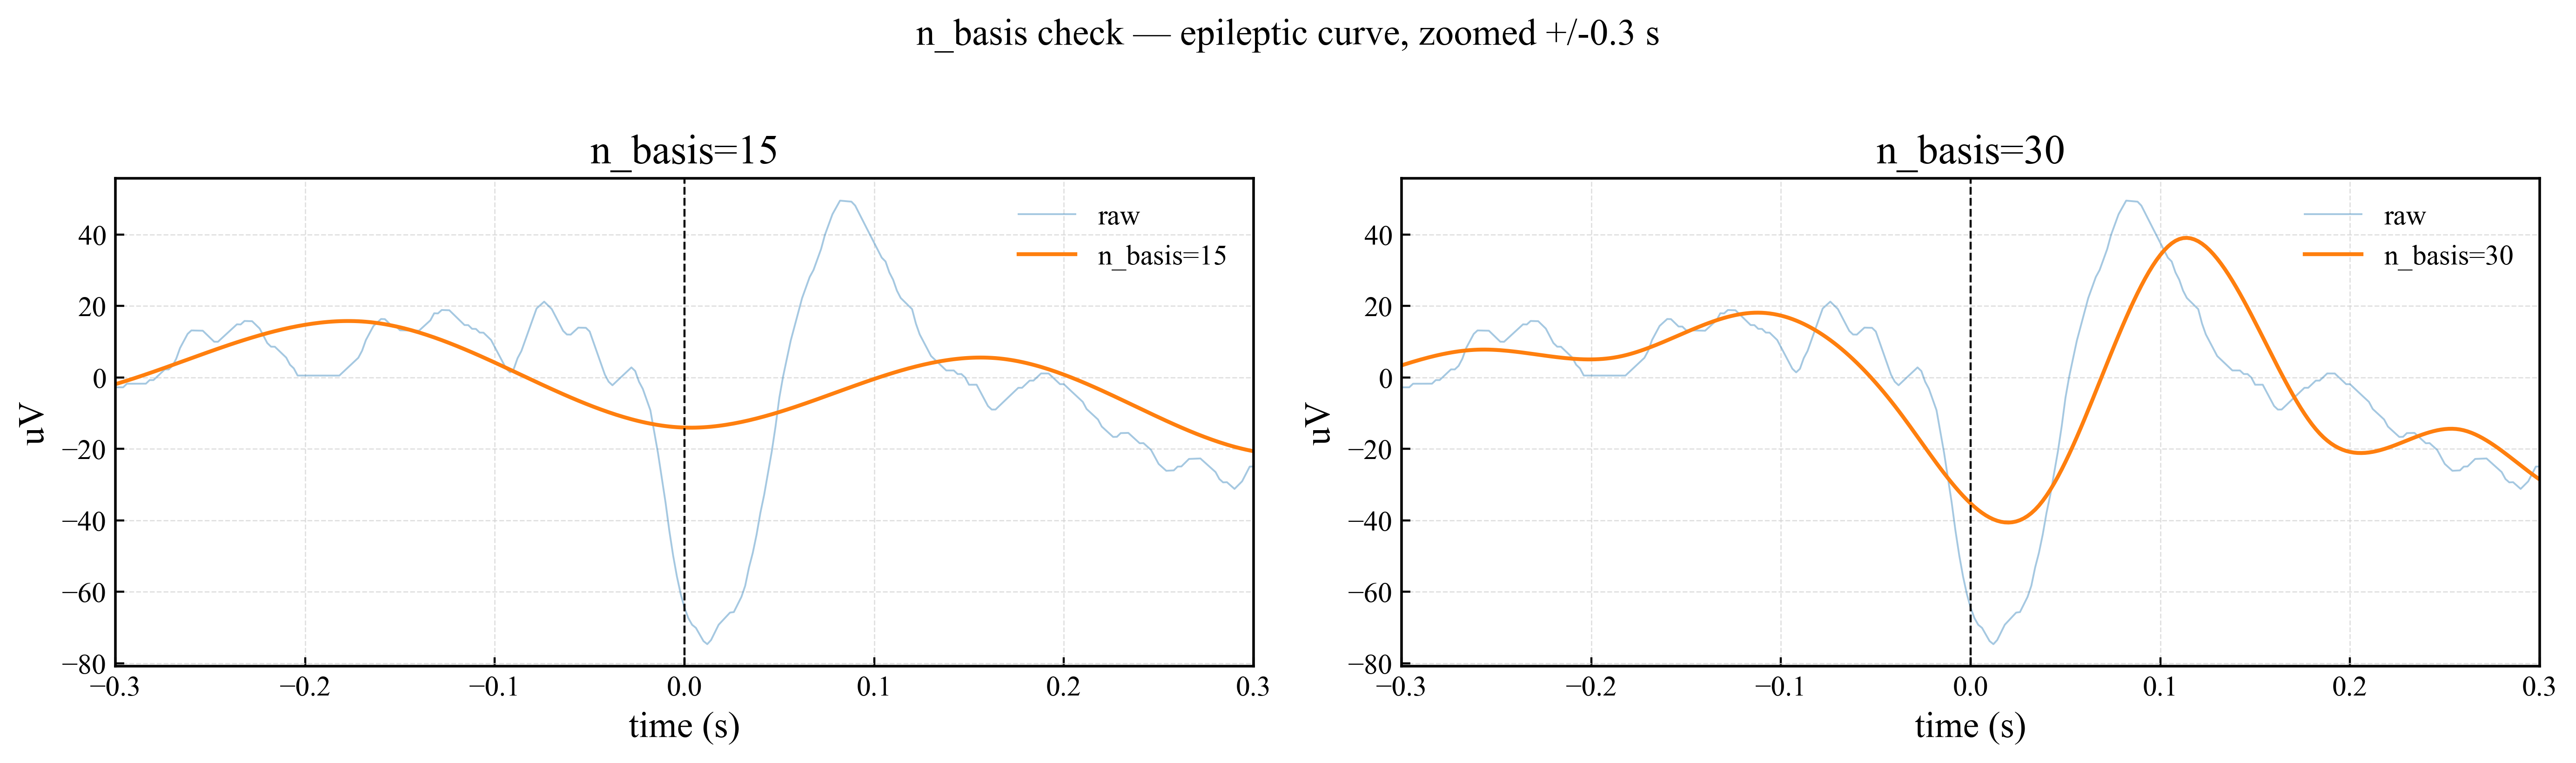

In [ ]:
domain  = (t[0], t[-1])
epi_idx = np.where(y == 1)[0][0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, nb in zip(axes, [30, 80]):
    sm    = BasisSmoother(BSplineBasis(domain_range=domain, n_basis=nb, order=4), return_basis=False)
    fd_sm = sm.fit_transform(fd[epi_idx : epi_idx + 1])
    ax.plot(t, fd.data_matrix[epi_idx, :, 0] * 1e6, alpha=0.4, lw=0.7, label='raw')
    ax.plot(t, fd_sm.data_matrix[0, :, 0] * 1e6, lw=1.5, label=f'n_basis={nb}')
    ax.axvline(0, color='k', ls='--', lw=0.8)
    ax.set_xlim(-0.3, 0.3)
    ax.set_xlabel('time (s)'); ax.set_ylabel('uV')
    ax.set_title(f'n_basis={nb}'); ax.legend()
plt.suptitle('n_basis check — epileptic curve, zoomed +/-0.3 s', y=1.02)
plt.tight_layout(); plt.show()

## Pipeline

Two-step split so `Pipeline(memory=...)` caches `SmoothRegister` independently.
Registration depends only on `n_basis` and `penalty`: 4x4=16 unique fits per inner fold,
reused across the 16 downstream (n_components, C) combinations that share them.

In [31]:
class SmoothRegister(BaseEstimator, TransformerMixin):
    """B-spline smooth -> resample -> Fisher-Rao registration.
    Outputs a dict; Pipeline(memory=...) caches this step on (n_basis, penalty).
    """
    def __init__(self, n_basis=40, penalty=0.1, n_reg_points=100):
        self.n_basis      = n_basis
        self.penalty      = penalty
        self.n_reg_points = n_reg_points

    def fit(self, X, y=None):
        domain = X.domain_range[0]
        self._smoother = BasisSmoother(
            BSplineBasis(domain_range=domain, n_basis=self.n_basis, order=4),
            return_basis=False)
        X_sm    = self._smoother.fit_transform(X)
        self._t = np.linspace(domain[0], domain[1], self.n_reg_points)
        self._reg = FisherRaoElasticRegistration(penalty=self.penalty)
        self._reg.fit(FDataGrid(X_sm(self._t).squeeze(-1), self._t))
        return self

    def transform(self, X):
        X_sm = self._smoother.transform(X)
        X_c  = FDataGrid(X_sm(self._t).squeeze(-1), self._t)
        X_al = self._reg.transform(X_c)
        return {
            'aligned': X_al.data_matrix[:, :, 0],
            'warps':   self._reg.warping_.data_matrix[:, :, 0],
            't':       self._t,
        }


class FPCAFeatures(BaseEstimator, TransformerMixin):
    """FPCA on amplitude, phase, or both. Receives dict from SmoothRegister."""
    def __init__(self, n_components=5, mode='amplitude'):
        self.n_components = n_components
        self.mode         = mode

    def fit(self, X, y=None):
        t = X['t']
        if self.mode in ('amplitude', 'both'):
            self._fpca_amp = FPCA(n_components=self.n_components)
            self._fpca_amp.fit(FDataGrid(X['aligned'], t))
        if self.mode in ('phase', 'both'):
            self._fpca_ph = FPCA(n_components=self.n_components)
            self._fpca_ph.fit(FDataGrid(X['warps'], t))
        return self

    def transform(self, X):
        t = X['t']
        feats = []
        if self.mode in ('amplitude', 'both'):
            feats.append(self._fpca_amp.transform(FDataGrid(X['aligned'], t)))
        if self.mode in ('phase', 'both'):
            feats.append(self._fpca_ph.transform(FDataGrid(X['warps'], t)))
        return np.hstack(feats)

In [32]:
PENALTIES = [0.01, 0.05, 0.1, 0.5] # previous used 0.1
N_BASES   = [30, 40, 60, 80] # previous used 40
N_COMPS   = [3, 5, 8, 10] # previous used 5
CS        = [0.01, 0.1, 1, 10] # previous used c = 1.0 (default)

def compute_metrics(y_true, y_prob, cert):
    auc      = roc_auc_score(y_true, y_prob)
    y_pred   = (y_prob >= 0.5).astype(int)
    spec     = np.mean(y_pred[cert == 'negative']         == 0)
    sens_clr = np.mean(y_pred[cert == 'clear_positive']   == 1)
    sens_unc = np.mean(y_pred[cert == 'unclear_positive'] == 1)
    return {'auc': auc, 'specificity': spec, 'sens_clear': sens_clr, 'sens_unclear': sens_unc}

n_combos = len(PENALTIES) * len(N_BASES) * len(N_COMPS) * len(CS)
print(f'Grid: {n_combos} combinations')
print(f'{len(PENALTIES)*len(N_BASES)} unique registration fits per inner fold (explicitly cached)')

Grid: 256 combinations
16 unique registration fits per inner fold (explicitly cached)


## Nested CV

- Outer 5-fold × inner 3-fold, stratified on `cert`, trained on binary `y`.
- **Registration cache shared across the three modes.** The outer/inner splits use
  `random_state=rep` and `rep*100+fold` — identical for every mode — and registration
  depends only on `(penalty, n_basis)`, never on the mode. So the expensive
  smoothing + Fisher-Rao + FPCA cache is built **once per outer fold** and reused by
  amplitude / phase / both, instead of recomputed three times.
- Two-level cache per outer fold:
  1. **Registration**: 16 unique `(penalty, n_basis)` fits × 3 inner folds = 48 calls,
     reused across all 256 grid combos.
  2. **FPCA scores**: amplitude and phase each fitted once at `MAX_NC`; the grid sweep
     slices `[:, :nc]` columns and runs only StandardScaler + LR — no FPCA in the inner loop.
- 10 repeats, **parallelised across repeats** (`joblib`, `n_jobs=-1`). Each outer fold
  tunes independently.
- Net vs the previous per-mode driver: registration/FPCA cost cut ~3× (mode sharing)
  and again by the core count (parallel repeats), with byte-identical results.

In [33]:
from joblib import Parallel, delayed

N_REPEATS = 10
OUTER_K   = 5
INNER_K   = 3
MAX_NC    = max(N_COMPS)   # fit FPCA once at 10, slice to 3/5/8/10 in grid sweep
MODES     = ['amplitude', 'phase', 'both']
N_JOBS    = -1            # parallelise over repeats (8 cores, 10 repeats)


def slice_feats(entry, mode, nc, split):
    """Slice cached amp/phase FPCA scores (fitted at MAX_NC) down to nc columns."""
    amp, ph = entry[f'amp_{split}'][:, :nc], entry[f'phase_{split}'][:, :nc]
    if mode == 'amplitude':
        return amp
    if mode == 'phase':
        return ph
    return np.hstack([amp, ph])


def process_repeat(rep):
    """One repeat: registration/FPCA cache built ONCE per outer fold and shared
    across all three modes (splits are seed-identical, registration is mode-independent).
    Returns oof probabilities and selected params per mode."""
    n   = len(y)
    oof    = {m: np.zeros(n) for m in MODES}
    params = {m: [] for m in MODES}
    outer_cv = StratifiedKFold(n_splits=OUTER_K, shuffle=True, random_state=rep)

    for fold, (tr_idx, te_idx) in enumerate(outer_cv.split(np.arange(n), cert)):
        y_tr    = y[tr_idx]
        cert_tr = cert[tr_idx]
        inner_splits = list(
            StratifiedKFold(n_splits=INNER_K, shuffle=True, random_state=rep * 100 + fold)
            .split(np.arange(len(tr_idx)), cert_tr)
        )

        # Shared cache: registration + amp & phase FPCA scores (at MAX_NC), per
        # (pen, nb, inner_fold). Built ONCE, reused across all 3 modes.
        # 16 (pen,nb) x 3 inner folds = 48 registrations per outer fold, not 3x that.
        cache = {}
        for pen, nb in product(PENALTIES, N_BASES):
            for i_fold, (i_tr, i_te) in enumerate(inner_splits):
                sr     = SmoothRegister(n_basis=nb, penalty=pen)
                reg_tr = sr.fit_transform(fd[tr_idx[i_tr]])
                reg_te = sr.transform(fd[tr_idx[i_te]])
                t_reg  = reg_tr['t']
                entry  = {'y_tr': y_tr[i_tr], 'y_te': y_tr[i_te]}
                for key, field in [('amp', 'aligned'), ('phase', 'warps')]:
                    fpca = FPCA(n_components=MAX_NC)
                    fpca.fit(FDataGrid(reg_tr[field], t_reg))
                    entry[f'{key}_tr'] = fpca.transform(FDataGrid(reg_tr[field], t_reg))
                    entry[f'{key}_te'] = fpca.transform(FDataGrid(reg_te[field], t_reg))
                cache[(pen, nb, i_fold)] = entry

        # Per-mode grid sweep (cheap: slice scores + StandardScaler + LR), refit, predict.
        for mode in MODES:
            best_score, best_p = -np.inf, None
            for pen, nb, nc, C in product(PENALTIES, N_BASES, N_COMPS, CS):
                scores = []
                for i_fold in range(INNER_K):
                    e    = cache[(pen, nb, i_fold)]
                    X_tr = slice_feats(e, mode, nc, 'tr')
                    X_te = slice_feats(e, mode, nc, 'te')
                    sc   = StandardScaler()
                    lr   = LogisticRegression(C=C, max_iter=1000, class_weight='balanced')
                    lr.fit(sc.fit_transform(X_tr), e['y_tr'])
                    scores.append(roc_auc_score(e['y_te'], lr.predict_proba(sc.transform(X_te))[:, 1]))
                score = np.mean(scores)
                if score > best_score:
                    best_score = score
                    best_p = {'sr__penalty': pen, 'sr__n_basis': nb,
                              'fpca__n_components': nc, 'lr__C': C}

            # Refit best params on full outer training set, predict held-out fold
            sr     = SmoothRegister(n_basis=best_p['sr__n_basis'], penalty=best_p['sr__penalty'])
            reg_tr = sr.fit_transform(fd[tr_idx])
            fpca   = FPCAFeatures(n_components=best_p['fpca__n_components'], mode=mode)
            X_tr_f = fpca.fit_transform(reg_tr)
            sc     = StandardScaler()
            lr     = LogisticRegression(C=best_p['lr__C'], max_iter=1000, class_weight='balanced')
            lr.fit(sc.fit_transform(X_tr_f), y_tr)

            reg_te          = sr.transform(fd[te_idx])
            oof[mode][te_idx] = lr.predict_proba(sc.transform(fpca.transform(reg_te)))[:, 1]
            params[mode].append(best_p)

        del cache

    return oof, params


t0 = time.time()
rep_results = Parallel(n_jobs=N_JOBS, verbose=10)(
    delayed(process_repeat)(rep) for rep in range(N_REPEATS)
)

# Aggregate: one metric dict per repeat per mode; params pooled across all outer folds.
ncv_results = {m: [] for m in MODES}
ncv_params  = {m: [] for m in MODES}
for oof, params in rep_results:
    for m in MODES:
        ncv_results[m].append(compute_metrics(y, oof[m], cert))
        ncv_params[m].extend(params[m])

print(f'\nDone in {(time.time() - t0) / 60:.1f} min')
for m in MODES:
    aucs = [r['auc'] for r in ncv_results[m]]
    print(f'  [{m}] AUC {np.mean(aucs):.3f}  (across {N_REPEATS} repeats)')

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of  10 | elapsed: 28.0min remaining: 65.4min
[Parallel(n_jobs=-1)]: Done   5 out of  10 | elapsed: 28.1min remaining: 28.1min
[Parallel(n_jobs=-1)]: Done   7 out of  10 | elapsed: 28.1min remaining: 12.1min



Done in 39.8 min
  [amplitude] AUC 0.824  (across 10 repeats)
  [phase] AUC 0.615  (across 10 repeats)
  [both] AUC 0.823  (across 10 repeats)


[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed: 39.8min finished


## Results

In [34]:
FIXED_AUC  = {'amplitude': 0.874, 'phase': 0.560, 'both': 0.857}
metrics    = ['auc', 'specificity', 'sens_clear', 'sens_unclear']
met_labels = ['AUC', 'Specificity', 'Sens clear+', 'Sens unclear+']

rows = []
for mode in ['amplitude', 'phase', 'both']:
    row = {'Condition': mode}
    for m, ml in zip(metrics, met_labels):
        vals = [r[m] for r in ncv_results[mode]]
        mn, p10, p90 = np.mean(vals), np.percentile(vals, 10), np.percentile(vals, 90)
        row[ml] = f'{mn:.3f}  ({p10:.3f}-{p90:.3f})'
    rows.append(row)

print(pd.DataFrame(rows).set_index('Condition').to_string())
print()
print('Comparison to fixed-setting single-loop CV:')
for mode in ['amplitude', 'phase', 'both']:
    tuned = np.mean([r['auc'] for r in ncv_results[mode]])
    print(f'  {mode:12s}  tuned {tuned:.3f}  fixed {FIXED_AUC[mode]:.3f}  delta {tuned - FIXED_AUC[mode]:+.3f}')

                            AUC           Specificity           Sens clear+         Sens unclear+
Condition                                                                                        
amplitude  0.824  (0.783-0.857)  0.843  (0.802-0.896)  0.786  (0.677-0.909)  0.656  (0.619-0.691)
phase      0.615  (0.544-0.696)  0.611  (0.511-0.674)  0.664  (0.545-0.727)  0.531  (0.428-0.628)
both       0.823  (0.794-0.861)  0.804  (0.733-0.872)  0.795  (0.636-0.868)  0.666  (0.591-0.731)

Comparison to fixed-setting single-loop CV:
  amplitude     tuned 0.824  fixed 0.874  delta -0.050
  phase         tuned 0.615  fixed 0.560  delta +0.055
  both          tuned 0.823  fixed 0.857  delta -0.034


## Selected parameter distribution

Each outer fold picks independently. (check before going with frequency)

In [35]:
for mode in ['amplitude', 'phase', 'both']:
    print(f'\n=== {mode}  ({len(ncv_params[mode])} outer folds total) ===')
    df_p = pd.DataFrame(ncv_params[mode])
    for col in df_p.columns:
        vc = df_p[col].value_counts().sort_index()
        print(f'  {col}: {dict(vc)}')


=== amplitude  (50 outer folds total) ===
  sr__penalty: {0.01: 22, 0.05: 15, 0.1: 12, 0.5: 1}
  sr__n_basis: {30: 32, 40: 7, 60: 9, 80: 2}
  fpca__n_components: {3: 10, 5: 24, 8: 11, 10: 5}
  lr__C: {0.01: 15, 0.1: 14, 1.0: 11, 10.0: 10}

=== phase  (50 outer folds total) ===
  sr__penalty: {0.01: 24, 0.05: 7, 0.1: 6, 0.5: 13}
  sr__n_basis: {30: 2, 60: 17, 80: 31}
  fpca__n_components: {3: 6, 5: 16, 8: 10, 10: 18}
  lr__C: {0.01: 15, 0.1: 12, 1.0: 12, 10.0: 11}

=== both  (50 outer folds total) ===
  sr__penalty: {0.01: 20, 0.05: 20, 0.1: 9, 0.5: 1}
  sr__n_basis: {30: 25, 40: 5, 60: 10, 80: 10}
  fpca__n_components: {3: 13, 5: 27, 8: 7, 10: 3}
  lr__C: {0.01: 5, 0.1: 4, 1.0: 13, 10.0: 28}
